In [25]:
import sys

sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

#load the necessary odometry modules
from cpsl_datasets.cpsl_ds import CpslDS
from cpsl_datasets.map_handler import MapHandler
from odometry.localization.icp2D_localization import icp2DLocalization
from odometry.plotting.plotter_kalman import PlotterKalman
from odometry.plotting.movies import MovieGenerator
from odometry.test_benches.temporal_density_pc_integrator_tb import TemporalDensityPCIntegratorTB
from odometry.test_benches._test_bench import _TestBench, PredictionSource, GroundTruthSource, OdomCoordinateFrame
from odometry.point_cloud_processing.accumulation.integrators.temporal_density_pc_integrator import TemporalDensityPCIntegrator


from odometry.point_cloud_processing.clustering.occlusion_aware_clustering import OcclusionAwareClustering
from odometry.point_cloud_processing.accumulation.pc_accumulator import GtPointLabelingStrategy


from mmwave_model_integrator.dataset_generators._online_dataset_generator import _OnlineDatasetGenerator
from mmwave_model_integrator.input_encoders._node_encoder import _NodeEncoder
from mmwave_model_integrator.ground_truth_encoders._gt_node_encoder import _GTNodeEncoder

#analyzer
from odometry.analyzers.analyzer import Analyzer

from dotenv import load_dotenv
import os

#loading enviroment variables
load_dotenv()

DATASET_PATH = "/data/RaGNNarok/ugv_datasets/"
MAP_DIRECTORY = "/data/RaGNNarok/ugv_datasets/maps/"
GENERATED_DATASETS_PATH = "/data/RaGNNarok/generated_datasets/"

In [26]:
# #setup the datasets
folder_name = "WILK_BASEMENT" #"WILK", "NORTH_VICON", "NORTH_1ST", "CPSL"
file_name = "wilk_basement_3" # "IcaRAus_ugv_wilk_2_5m", "north_vicon_1", "north_1st_1", "IcaRAus_ugv_cpsl_1_5m"
# file_name = "WILK_Multipath_Test_5" #for point cloud comparison (frame 1340)
# file_name = "WILK_Path_1_Same_Side_Dynamic_1"
# file_name = "wilk_basement_3" #wilk_basement_2 for point cloud processing (frame 780)

normalize_frames = True
num_frames_history = 50
config_label = "IcaRAus_gnn_{}fh_grids".format(num_frames_history)
results_parent_folder = "{}_train".format(config_label)
print(os.path.join(DATASET_PATH,folder_name,file_name))
dataset = CpslDS(
    dataset_path=os.path.join(DATASET_PATH,folder_name,file_name),
    radar_pc_folder="radar_combined",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)
print(dataset.num_frames)

map_handler = MapHandler(
    maps_folder=MAP_DIRECTORY,
    map_file="wilk_basement_revB.yaml"#"cpsl_map.yaml", "wilk_map", "north_vicon_1", "north_1st_map"
)

/data/RaGNNarok/ugv_datasets/WILK_BASEMENT/wilk_basement_3
found 7288 radar point cloud samples
found 7288 lidar samples
found 7288 camera samples
found 7288 imu (orientation only) samples
found 7288imu (full data) samples
found 7288 vehicle velocity samples
7288
loaded map from /data/RaGNNarok/ugv_datasets/maps/wilk_basement_revB.yaml
loaded map free space from /data/RaGNNarok/ugv_datasets/maps/wilk_basement_revB.yaml


In [27]:
#initialize the localizers
radar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.25,#0.1
    icp_best_points_percentile=60, #80
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=7, #7
    icp_max_iterations=5, #20
    self_detection_radius_m=0 #originally 1.5
)

lidar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.1, #was 0.6, try 0.1
    icp_best_points_percentile=50, #was 50 - try 75
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=10,
    icp_max_iterations=5,
    self_detection_radius_m=1.0 #was 0.25, try 1.0
)

In [28]:
#initialize the dataset encoders
input_encoder = _NodeEncoder()
gt_encoder = _GTNodeEncoder()

#initialize the dataset generator
generated_dataset_path = os.path.join(GENERATED_DATASETS_PATH,"{}_train".format(config_label))
dataset_generator = None

loaded map with 19375 points
gt icp estimated heading:-4.975875116388919 deg, pose:[-0.01746963  0.05600943]
loaded map with 19375 points


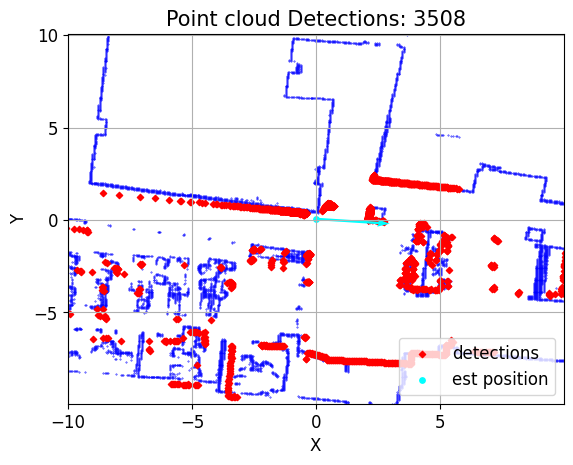

In [29]:
point_cloud_integrator = TemporalDensityPCIntegrator(
        gt_distance_threshold_m=0.4,
        num_frames_history_gt=1,
        valid_fovs_deg=[(-70,70),(110,-110)],
        num_frames_history=num_frames_history,
        min_detection_radius=1.0,
        max_detection_radius=8.0,
        grid_resolution_m=0.1,
        subsample_percentage=1.0,
        gt_point_labeling_strategy=GtPointLabelingStrategy.USE_VALID_POINTS_FOR_GT_CLASSIFICATION,
        gt_occlusion_aware_clustering=OcclusionAwareClustering(
            clustering_eps=0.5,
            clustering_min_samples=12,
            angle_res_rad=0.017,
            occlusion_threshold=0.7,
            subsample_percentage=0.20,
            remove_occluded=True,
            filter_method='ray_trace'
        ),
        occlusion_aware_clustering=OcclusionAwareClustering(
            clustering_eps=0.25,
            clustering_min_samples=10,
            angle_res_rad=0.017,
            occlusion_threshold=0.9,
            subsample_percentage=0.8,
            remove_occluded=False,
            filter_method='ray_trace' #ray_trace or overlap
        )
    )

#initialize the test bench
test_bench = TemporalDensityPCIntegratorTB(
    localizer=radar_odometry,
    gt_localizer=lidar_odometry,
    map_handler=map_handler,
    dataset=dataset,
    point_cloud_integrator=point_cloud_integrator,
    dynamic_point_cloud_integrator=None,
    model_dataset_generator=None,
    use_filters=True,
    prediction_source=PredictionSource.IMU_AND_VEL,
    gt_source=GroundTruthSource.LIDAR,
    odom_frame=OdomCoordinateFrame.FLU
)

start_heading = np.deg2rad(-5)
start_pose = np.array([0.00,0.00])

#initialize the localization
new_heading_rad,new_pose_m = test_bench.init_localization(
    est_start_heading_rad=start_heading,
    est_start_pose_m=start_pose,
    show=True
)

#initialize the filter
test_bench.init_filter(
    est_start_heading_rad=new_heading_rad,
    est_start_position_m=new_pose_m,
    start_time_s=test_bench.get_dataset_start_time(idx=0),
    gyro_bias=-0.0024
)

In [30]:
generate_movie = False
if generate_movie:
    #loading directory from .env file
    MOVIE_TEMP_DIRECTORY = os.getenv("MOVIE_TEMP_DIRECTORY")

    #initialize the movie maker
    movie_generator = MovieGenerator(
        temp_dir_path=os.path.join(MOVIE_TEMP_DIRECTORY,results_parent_folder)
    )
    movie_generator.initialize_figure(
        nrows=3,
        ncols=3,
        figsize=(15,15)
    )
    
    movie_folder="{}/Movies".format(results_parent_folder)
    create_dir(movie_folder)
    movie_generator.start_movie(
        video_file_name="{}/{}.mp4".format(movie_folder,file_name),
        fps=10
    )
else:
    movie_generator=None

In [31]:
#run the dataset
# end_idx = dataset.num_frames
end_idx = 700
test_bench.run(
    max_frame=end_idx,
    gt_enabled=False,
    movie_generator=movie_generator,
    generate_dataset=False,
    normalize_frames=normalize_frames)

if generate_movie:
    movie_generator.save_movie()

100%|██████████| 700/700 [00:15<00:00, 44.78it/s]


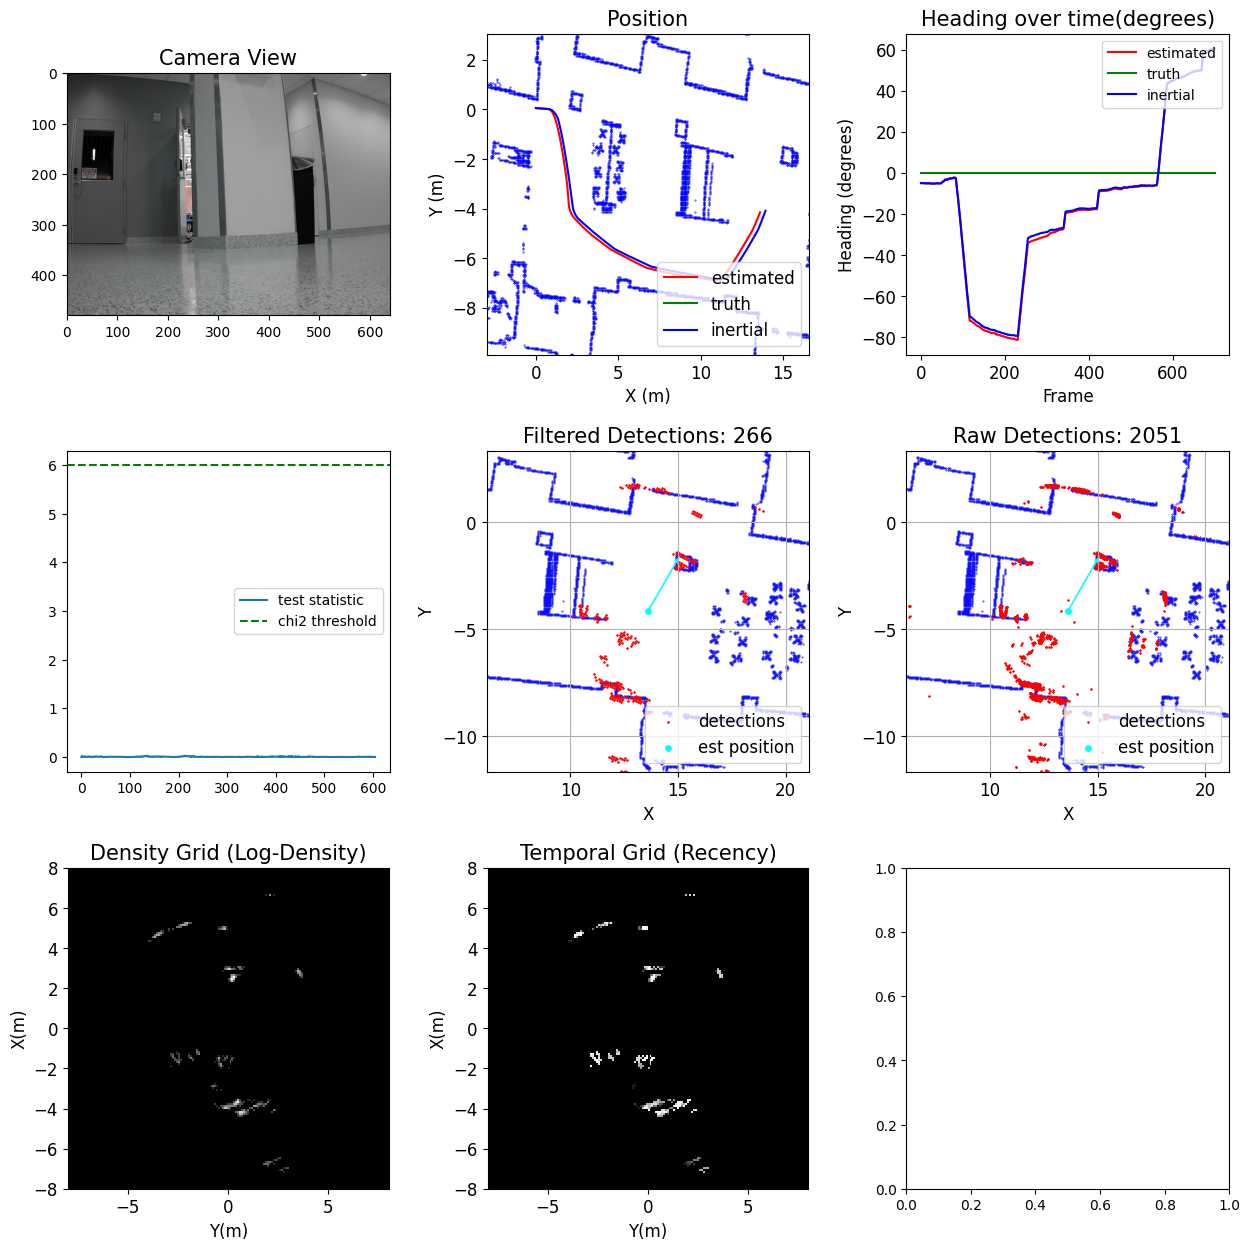

In [33]:
axs = test_bench.plot_compilation(
    idx=end_idx-1,
    show=True
)